# Previsione prezzo bitcoin basato su sentimental analisys 

Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26

Realizzato da: *Tverdohleb Egor 0001114726*

Email istituzionale: egor.tverdohleb@studio.unibo.it

## Importo librerie
Le libreria che andremo ad utilizzare sono:
 - *pandas*: per gestire dati tabulari
 - *numpy*: per operare su array multidimensionalei
 - *yfinance*: per estrapolare i dati utilizzati
 - *matplotlib*: per creare grafici

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

%matplotlib inline

## Estreazione dati

Andiamo ad estrapolare i dati relativi alla criptovaluta *bitcoin* degli ultimi 5 anni

In [2]:
print("Scaricamento dati in corso")

btc = yf.Ticker("BTC-USD")
df = btc.history(period="5y")
df.head()
display(df.tail())

Scaricamento dati in corso


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-24 00:00:00+00:00,76670.656250,77372.539062,76019.890625,76981.125000,20572738918,0.0,0.0
2026-05-25 00:00:00+00:00,76981.125000,77804.921875,76833.039062,77279.929688,19808387601,0.0,0.0
2026-05-26 00:00:00+00:00,77280.125000,77990.867188,75569.468750,75825.734375,35999475458,0.0,0.0
2026-05-27 00:00:00+00:00,75825.304688,76014.296875,74136.500000,74344.703125,33802172927,0.0,0.0
2026-05-28 00:00:00+00:00,74332.937500,74446.328125,72640.757812,73479.148438,42036649984,0.0,0.0


Possiamo notare che Dividends e Stock Splits sono dati non popolati nel dataset, essi non hanno senso nella specifica ottica delle criptovalute pur essendo dati sensati in altri ambiti finanziari

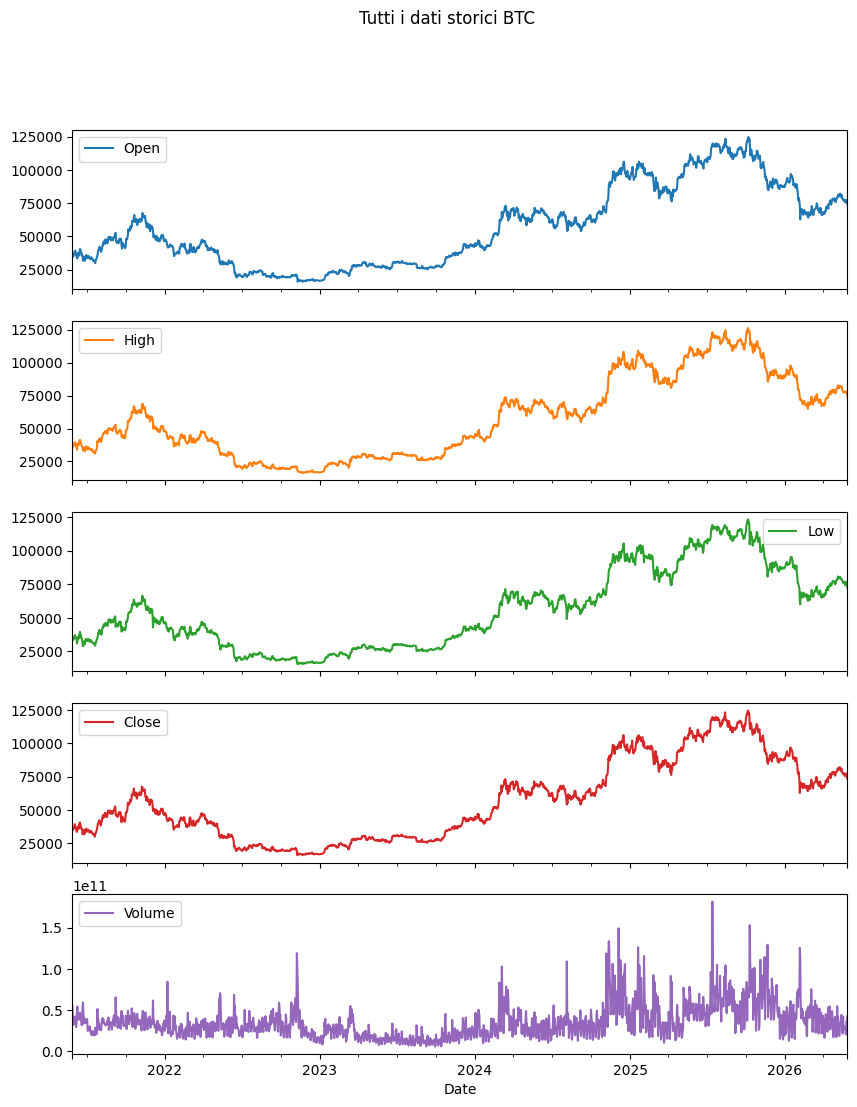

In [3]:
df = df.drop(columns=['Dividends', 'Stock Splits'])
df.plot(subplots=True, figsize=(10, 12), title="Tutti i dati storici BTC")
plt.show()

Essendo bitcoin una moneta virtuale viene venduta su un mercato 24 su 24, ne consegue che il valore di open e close perde è coincidente. Nello specifico l'open di uno specifico giorno equivale al close del giorno precedente

In [4]:
open_oggi = df['Open'][1:].round(2)
close_ieri = df['Close'].shift(1)[1:].round(2)

sono_uguali = (open_oggi == close_ieri)

print("Open sempre uguale al Close precedente?", sono_uguali.all())
print("\nConteggio giorni:")
print(sono_uguali.value_counts())

Open sempre uguale al Close precedente? False

Conteggio giorni:
False    1808
True       18
Name: count, dtype: int64


Sorprendentemente troviamo valori diseguali, una possibile spiegazione è la latenza di rete durante la "fotografia" che viene registrata da yfinance. Verifichiamo a quanto ammonta la disugualianza media tra close e open

In [5]:
df['Gap_Assoluto_$'] = df['Open'] - df['Close'].shift(1)
df['Gap_Percentuale_%'] = (df['Gap_Assoluto_$'] / df['Close'].shift(1)) * 100

gap_data = df.dropna(subset=['Gap_Percentuale_%'])
gap_medio_usd = gap_data['Gap_Assoluto_$'].abs().mean()
gap_medio_pct = gap_data['Gap_Percentuale_%'].abs().mean()
gap_max_pct = gap_data['Gap_Percentuale_%'].abs().max()
print(f"Gap Medio in Dollari: {gap_medio_usd:.4f} $")
print(f"Gap Medio in Percentuale: {gap_medio_pct:.6f} %")
print(f"Gap Massimo Registrato: {gap_max_pct:.4f} %")

df = df.drop(columns=["Gap_Assoluto_$","Gap_Percentuale_%"])

Gap Medio in Dollari: 11.8313 $
Gap Medio in Percentuale: 0.024941 %
Gap Massimo Registrato: 3.7911 %


Come predetto il gap, tranne in qualche caso straordinario, è virtualmente nullo. Procediamo quindi ad eliminare la colonna open rinominando la close come prize inteso alle ore 24 del giorno

In [6]:
df = df.drop(columns=['Open'])
df = df.rename(columns={'Close': 'Prize'})

Proseguiamo aggiungendo un dato significativo, ossia la media della volatilità (differenza tra High e Low) degli ultimi 30 giorni. Questa potrebbe rivelare interessanti correlazioni con il sentiment analysis che attueremo successivamente

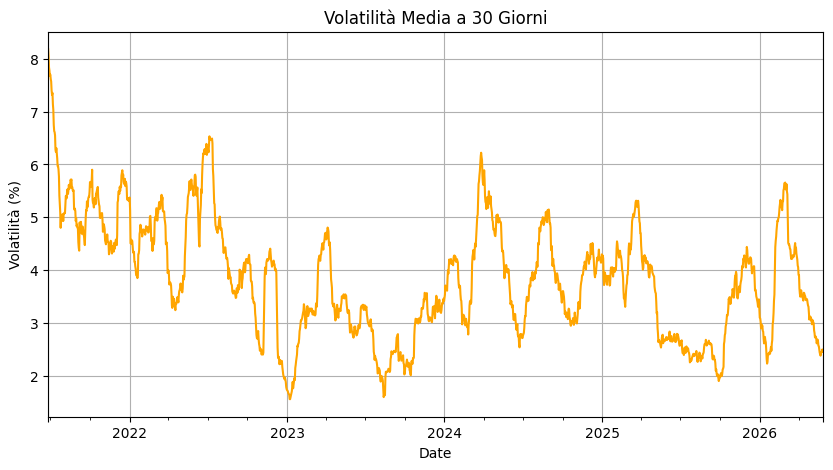

In [7]:
df['Daily_Range_%'] = ((df['High'] - df['Low']) / df['Prize']) * 100
df['Volatility_30d'] = df['Daily_Range_%'].rolling(window=30).mean()
df = df.dropna(subset=['Volatility_30d'])
df = df.drop(columns=["Daily_Range_%"])

df['Volatility_30d'].plot(figsize=(10, 5), color='orange', title="Volatilità Media a 30 Giorni")
plt.ylabel("Volatilità (%)")
plt.grid(True)
plt.show()

### Significato delle colonne

Le feature presenti nel Dataset sono:

* **Date**: (Indice del dataframe) la data di calendario a cui si riferiscono le misurazioni giornaliere.
* **High**: prezzo massimo raggiunto dal Bitcoin durante l'intera giornata.
* **Prize**: prezzo del Bitcoin al termine della giornata. Questa sarà la variabile "target" che tenteremo di predirre.
* **Volume**: volume totale degli scambi registrati in quella giornata, ovvero l'ammontare complessivo di transazioni effettuate sul mercato per quell'asset.
* **Volatility 30d**: volatilità media registrata negli ultimi 30 giorni

Data la notoria difficolta nel prevedere il mercato finanziario andiamo ad unire al dataset raccolto i dati di un altro dataset contenente un raccolta di "tweet" riguardanti il bitcoin. L'idea è di vedere il potere predittivo dell'entusiasmo o meno riguardante la cryptovaluta

In [8]:
df_tweets_1 = pd.read_csv('dati/Bitcoin_tweets.csv', lineterminator='\n', low_memory=False)
df_tweets_2 = pd.read_csv('dati/Bitcoin_tweets_dataset_2.csv', lineterminator='\n', low_memory=False)
df_tweets = pd.concat([df_tweets_1, df_tweets_2], ignore_index=True)
display(df_tweets.head())

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet
0,DeSota Wilson,"Atlanta, GA","Biz Consultant, real estate, fintech, startups...",2009-04-26 20:05:09,8534.0,7605,4838,False,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...,['bitcoin'],Twitter Web App,False
1,CryptoND,NaN,😎 BITCOINLIVE is a Dutch platform aimed at inf...,2019-10-17 20:12:10,6769.0,1532,25483,False,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""...","['Thursday', 'Btc', 'wallet', 'security']",Twitter for Android,False
2,Tdlmatias,"London, England","IM Academy : The best #forex, #SelfEducation, ...",2014-11-10 10:50:37,128.0,332,924,False,2021-02-10 23:54:48,"Guys evening, I have read this article about B...",NaN,Twitter Web App,False
3,Crypto is the future,NaN,I will post a lot of buying signals for BTC tr...,2019-09-28 16:48:12,625.0,129,14,False,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...,"['Bitcoin', 'FX', 'BTC', 'crypto']",dlvr.it,False
4,Alex Kirchmaier 🇦🇹🇸🇪 #FactsSuperspreader,Europa,Co-founder @RENJERJerky | Forbes 30Under30 | I...,2016-02-03 13:15:55,1249.0,1472,10482,False,2021-02-10 23:54:06,This network is secured by 9 508 nodes as of t...,['BTC'],Twitter Web App,False


Andiamo a scremare le colonne che non ci serviranno

In [9]:
df_tweets = df_tweets.drop(columns=["user_name","user_location","user_description","user_created","user_verified","hashtags","source","is_retweet"])
display(df_tweets.head())

,user_followers,user_friends,user_favourites,date,text
0,8534.0,7605,4838,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...
1,6769.0,1532,25483,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""..."
2,128.0,332,924,2021-02-10 23:54:48,"Guys evening, I have read this article about B..."
3,625.0,129,14,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...
4,1249.0,1472,10482,2021-02-10 23:54:06,This network is secured by 9 508 nodes as of t...


Aggiungiamo al dataframe totale il numero di tweet giornalieri

In [12]:
tweet_counts = tweet_counts.set_index('Date')
df_final = df_clean.join(tweet_counts, how='left')
df_final['Tweet_Volume'] = df_final['Tweet_Volume'].fillna(0)
display(df_final.tail(10))

KeyError: 'Tweet_Volume'